In [4]:
from src import MergeData, ExtractFeatures, StatisticalAnalyzer
import pandas as pd
import numpy as np

In [5]:

swat_path = 'data\\SWaT_processed_data.csv'
pcap_path = 'data\\pcap_network_features.csv'

In [6]:
merge = MergeData(swat_path, pcap_path)
df_merged = merge.merge()
print("df_merged shape:", df_merged.shape)

# ograniczenie do wierszy z danymi sieciowymi (okno Ataku 2, ~4356s)
network_cols = ["pkt_count", "total_bytes", "avg_pkt_len"]
df_merged = df_merged.dropna(subset=network_cols).reset_index(drop=True)
print("df_merged po ograniczeniu do okna sieciowego:", df_merged.shape)


df_merged shape: (13201, 88)
df_merged po ograniczeniu do okna sieciowego: (4361, 88)


In [7]:
df_csv = pd.read_csv('data/pcap_network_features.csv')
print("Dane z pcap_network_features.csv:", df_csv.head(5))

Dane z pcap_network_features.csv:    sec_timestamp  pkt_count  total_bytes  avg_pkt_len             datetime
0     1575605700      23504      2646382   112.592835  2019-12-06 04:15:00
1     1575605701      24155      2793602   115.653157  2019-12-06 04:15:01
2     1575605702      24138      2739949   113.511849  2019-12-06 04:15:02
3     1575605703      25476      2765378   108.548359  2019-12-06 04:15:03
4     1575605704      23658      2684782   113.483050  2019-12-06 04:15:04


In [8]:
ef = ExtractFeatures(
    windows=[5, 10, 30],
    network_cols=["pkt_count", "total_bytes", "avg_pkt_len"],
    process_cols=["LIT101.Pv", "FIT101.Pv"],       # dobierz kluczowe czujniki z Historian
    binary_state_cols=["P101.Status", "MV101.Status"],  # zawory/pompy z Twojego zbioru
    fft_cols=["FIT101.Pv"],                          # nawiązanie do STFT z rozdz. 2
    fft_window=30,                                   # długość okna próbek użycia do liczenia FFT
    lag_steps=[1, 5, 10],
    
)
df_out = ef.extract_features(df_merged)

#print(df_out.head())
#print(df_features.describe())
#print(df_out.select_dtypes(include='number').describe().T) 


In [9]:
df_out.to_csv('data/features_extracted.csv', index=False)

In [10]:
inf_mask = np.isinf(df_out.select_dtypes(include=[np.number]))
cols_with_inf = inf_mask.sum()
cols_with_inf = cols_with_inf[cols_with_inf > 0].sort_values(ascending=False)
print(cols_with_inf)

Series([], dtype: int64)


### problem NaN i inf 
wynik standaryzacji Z-score tylko na dobrych wartościach, efekt uboczny metodologii z rozdz 2. 

In [11]:
np.random.seed(0)
n = 300

# symulacja kolumny procesowej ktora ma sigma=0 w kalibracji i inf w momencie ataku
process_with_inf = np.zeros(n)
process_with_inf[250:260] = np.inf   # symulacja realnego zjawiska z ich danych
process_with_inf[260:270] = -np.inf

df = pd.DataFrame({
    'pkt_count': np.random.poisson(24000, n),
    'total_bytes': np.random.normal(2_600_000, 100000, n),
    'avg_pkt_len': np.random.normal(113, 5, n),
    'LIT101.Pv': np.sin(np.linspace(0, 20, n)) + np.random.normal(0, 0.05, n),
    'FIT101.Pv': process_with_inf,
    'P101.Status': np.random.choice([0,1], size=n),
})

ef = ExtractFeatures(
    windows=[5, 10, 30],
    network_cols=['pkt_count', 'total_bytes', 'avg_pkt_len'],
    process_cols=['LIT101.Pv', 'FIT101.Pv'],
    binary_state_cols=['P101.Status'],
    fft_cols=['FIT101.Pv'],
    fft_window=30,
    lag_steps=[1,5,10],
)

out = ef.extract_features(df)
print('---')
print('Shape:', out.shape)
print('NaN total:', out.isna().sum().sum())
print('Inf total:', np.isinf(out.select_dtypes(include=[np.number])).sum().sum())


[ExtractFeatures] UWAGA: 20 wartości inf w 1 kolumnach wejściowych (prawdopodobnie sigma=0 w oknie kalibracyjnym standaryzacji Z-score). Capuję do obserwowanego zakresu skończonego:
  - FIT101.Pv: 20 wartości -> capped to [0.0000, 0.0000]
---
Shape: (300, 163)
NaN total: 0
Inf total: 0


In [12]:
assert df_out.isna().sum().sum() == 0, "Znaleziono NaN po ekstrakcji cech!"
assert np.isinf(df_out.select_dtypes(include=[np.number])).sum().sum() == 0, "Znaleziono inf po ekstrakcji cech!"
print("Walidacja jakości danych: OK")

Walidacja jakości danych: OK


Standaryzacja Z-score oparta na oknie kalibracyjnym wolnym od ataków (rozdz. 2.1.4) doprowadziła do wystąpienia wartości nieskończonych w N obserwacjach dla K zmiennych stanowych, co wynikało z zerowej wariancji tych zmiennych w oknie referencyjnym i ich zmiany podczas ataku. Wartości te capowano do zaobserwowanego zakresu skończonego, zachowując informację o ekstremalnym odchyleniu.

In [13]:

print(df_out.head())

   P1_STATE  LIT101.Pv  FIT101.Pv  MV101.Status  P101.Status  P102.Status  \
0 -1.133272   0.836151    -0.3966      -0.25818    -1.291073          0.0   
1 -1.133272   0.839541    -0.3966      -0.25818    -1.291073          0.0   
2 -1.133272   0.833731    -0.3966      -0.25818    -1.291073          0.0   
3 -1.133272   0.833246    -0.3966      -0.25818    -1.291073          0.0   
4 -1.133272   0.835667    -0.3966      -0.25818    -1.291073          0.0   

   P2_STATE  FIT201.Pv  AIT201.Pv  AIT202.Pv  ...  FIT101.Pv_lag_10  \
0       0.0  -1.294814   0.820767   0.463565  ...           -0.3966   
1       0.0  -1.294814   0.820767   0.469404  ...           -0.3966   
2       0.0  -1.294814   0.820767   0.475246  ...           -0.3966   
3       0.0  -1.294814   0.820767   0.478165  ...           -0.3966   
4       0.0  -1.294814   0.820767   0.498607  ...           -0.3966   

   P101.Status_switch_count_5s  P101.Status_switch_count_10s  \
0                          0.0                

In [14]:
print(df_out.describe())

           P1_STATE    LIT101.Pv    FIT101.Pv  MV101.Status  P101.Status  \
count  4.361000e+03  4361.000000  4361.000000   4361.000000  4361.000000   
mean  -1.133272e+00     0.252643     0.181280     -0.066197    -0.171819   
min   -1.133272e+00    -3.145919    -0.396600     -3.962787    -1.291073   
25%   -1.133272e+00     0.028989    -0.396600     -0.258180    -1.291073   
50%   -1.133272e+00     0.625524    -0.396600     -0.258180     0.774550   
75%   -1.133272e+00     0.838089     1.400235     -0.258180     0.774550   
max   -1.133272e+00     1.071957     3.056567      3.446427     0.774550   
std    2.220701e-16     0.964677     1.044127      0.884050     1.029305   

       P102.Status  P2_STATE    FIT201.Pv    AIT201.Pv    AIT202.Pv  ...  \
count       4361.0    4361.0  4361.000000  4361.000000  4361.000000  ...   
mean           0.0       0.0    -0.174627     0.084138    -0.042523  ...   
min            0.0       0.0    -1.295042    -1.178149    -1.365504  ...   
25%        

statystyki opisowe

In [48]:
sa = StatisticalAnalyzer(target_col="y")

desc = sa.descriptive_statistics(df_out)
print(desc[0].head())
print(desc[1].head())

                  mean           std       min       50%       max
P1_STATE     -1.133272  4.441514e-16 -1.133272 -1.133272 -1.133272
LIT101.Pv     0.235455  1.006152e+00 -3.145919  0.630366  1.071957
FIT101.Pv    -0.003834  9.846329e-01 -0.396600 -0.396600  3.056567
MV101.Status -0.023921  9.714852e-01 -3.962787 -0.258180  3.446427
P101.Status  -0.154807  1.027761e+00 -1.291073  0.774550  0.774550
                  mean           std       min       50%       max
P1_STATE     -1.133272  2.221858e-16 -1.133272 -1.133272 -1.133272
LIT101.Pv     0.330694  7.434880e-01 -1.738830  0.500116  1.071957
FIT101.Pv     1.021940  8.813847e-01 -0.396600  1.568877  1.568877
MV101.Status -0.258180  0.000000e+00 -0.258180 -0.258180 -0.258180
P101.Status  -0.249075  1.033427e+00 -1.291073  0.774550  0.774550


test KS

In [49]:
ks_results = sa.ks_test(df_out)
print(ks_results.head(15))

               feature  ks_statistic        p_value  significant
0            FIT101.Pv      0.575673  4.530535e-200         True
1     FIT101.Pv_ewm_5s      0.570637  2.609578e-196         True
2     FIT101.Pv_max_5s      0.568958  4.571042e-195         True
3      FIT101.Pv_lag_1      0.567921  2.666060e-194         True
4    FIT101.Pv_mean_5s      0.567839  3.063421e-194         True
5    FIT101.Pv_max_10s      0.560564  6.349628e-189         True
6    FIT101.Pv_ewm_10s      0.560564  6.349628e-189         True
7   FIT101.Pv_mean_10s      0.559445  4.097006e-188         True
8     FIT101.Pv_min_5s      0.551379  2.425758e-182         True
9      FIT101.Pv_lag_5      0.536912  2.882495e-172         True
10   FIT101.Pv_max_30s      0.526988  1.468214e-165         True
11  FIT101.Pv_mean_30s      0.525869  8.189047e-165         True
12   FIT101.Pv_min_10s      0.521012  1.349319e-161         True
13   FIT101.Pv_ewm_30s      0.518841  3.591802e-160         True
14    FIT101.Pv_lag_10   

In [50]:
adf_result = sa.adf_test(df_out["FIT101.Pv"])
print(adf_result)

{'adf_statistic': -3.737254580247682, 'p_value': 0.0036186267431782063, 'n_lags': 5, 'n_obs': 4355, 'critical_values': {'1%': np.float64(-3.4318524474416483), '5%': np.float64(-2.862203897664062), '10%': np.float64(-2.5671233972458647)}, 'is_stationary': True}


macierz korelacji

In [51]:
# 1. Usuń stałe cechy
const_feats = sa.find_constant_features(df_out)
print(f"Usuwam {len(const_feats)} stałych cech")
df_clean = df_out.drop(columns=const_feats)

# 2. Usuń redundancję (silnie skorelowane duplikaty)
corr = sa.correlation_matrix(df_clean)
selection = sa.select_uncorrelated_features(corr, threshold=0.9)
print(f"Zachowuję {len(selection['keep'])} z {len(corr.columns)} cech")

df_final = df_clean[selection["keep"] + ["y"]]
df_final.to_csv("data/features_selected.csv", index=False)

Usuwam 43 stałych cech
Zachowuję 123 z 202 cech


In [52]:
corr = sa.correlation_matrix(df_out)
print("Kształt macierzy korelacji:", corr.shape)   # jeśli (0,0) -> problem w correlation_matrix
print(corr.iloc[:5, :5])

pairs = sa.top_correlated_pairs(corr, threshold=0.9)
print("Liczba par >= 0.7:", len(pairs))
print(pairs.head())

Kształt macierzy korelacji: (245, 245)
              P1_STATE  LIT101.Pv  FIT101.Pv  MV101.Status  P101.Status
P1_STATE           NaN        NaN        NaN           NaN          NaN
LIT101.Pv          NaN   1.000000  -0.387559     -0.405052    -0.364185
FIT101.Pv          NaN  -0.387559   1.000000      0.616953    -0.130025
MV101.Status       NaN  -0.405052   0.616953      1.000000    -0.085750
P101.Status        NaN  -0.364185  -0.130025     -0.085750     1.000000
Liczba par >= 0.7: 339
            feature_1          feature_2  correlation
0         P201.Status        P203.Status     1.000000
1         avg_pkt_len      bytes_per_pkt     1.000000
2   LIT101.Pv_mean_5s   LIT101.Pv_ewm_5s     0.999993
3  LIT101.Pv_mean_10s  LIT101.Pv_ewm_10s     0.999985
4    LIT101.Pv_ewm_5s    LIT101.Pv_lag_1     0.999943


In [53]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


In [54]:
def plot_full_clustermap(corr_matrix: pd.DataFrame):
    """
    Wyświetla pełną macierz korelacji z hierarchicznym grupowaniem.
    """

    corr_for_clustering = corr_matrix.fillna(0)

    g = sns.clustermap(
        corr_for_clustering,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        figsize=(14, 14),
        xticklabels=False,
        yticklabels=False,
        dendrogram_ratio=0.08,
        cbar_pos=(0.02, 0.83, 0.03, 0.15),
    )

    g.fig.suptitle(
        "Macierz korelacji cech (uporządkowana hierarchicznie)",
        y=1.02,
        fontsize=13,
    )

    plt.show()

    return g
 
def plot_top_features_heatmap(
    corr_matrix: pd.DataFrame,
    top_n=30,
):
    """
    Wyświetla heatmapę top_n cech o największym zaangażowaniu
    w korelacje.
    """

    abs_corr = corr_matrix.abs().fillna(0)

    for col in abs_corr.columns:
        abs_corr.loc[col, col] = 0

    involvement = abs_corr.sum(axis=1).sort_values(ascending=False)

    top_features = involvement.head(top_n).index.tolist()

    subset = corr_matrix.loc[top_features, top_features]

    fig, ax = plt.subplots(
        figsize=(max(10, top_n * 0.35),
                 max(8, top_n * 0.35))
    )

    sns.heatmap(
        subset,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        annot=top_n <= 25,
        fmt=".2f",
        annot_kws={"size": 7},
        square=True,
        linewidths=0.4,
        linecolor="#1a1a1a",
        cbar_kws={
            "shrink": 0.7,
            "label": "Współczynnik korelacji Pearsona"
        },
        ax=ax,
    )

    ax.set_title(
        f"Top {top_n} cech wg zaangażowania w korelacje",
        fontsize=12,
        pad=12,
    )

    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()

    plt.show()

    return fig, ax


In [ ]:
# numeric_df = df_out.select_dtypes(include="number").copy()

# constant_cols = numeric_df.columns[
#     numeric_df.nunique() <= 1
# ]

# numeric_df = numeric_df.drop(columns=constant_cols)

# corr = numeric_df.corr(method="pearson")

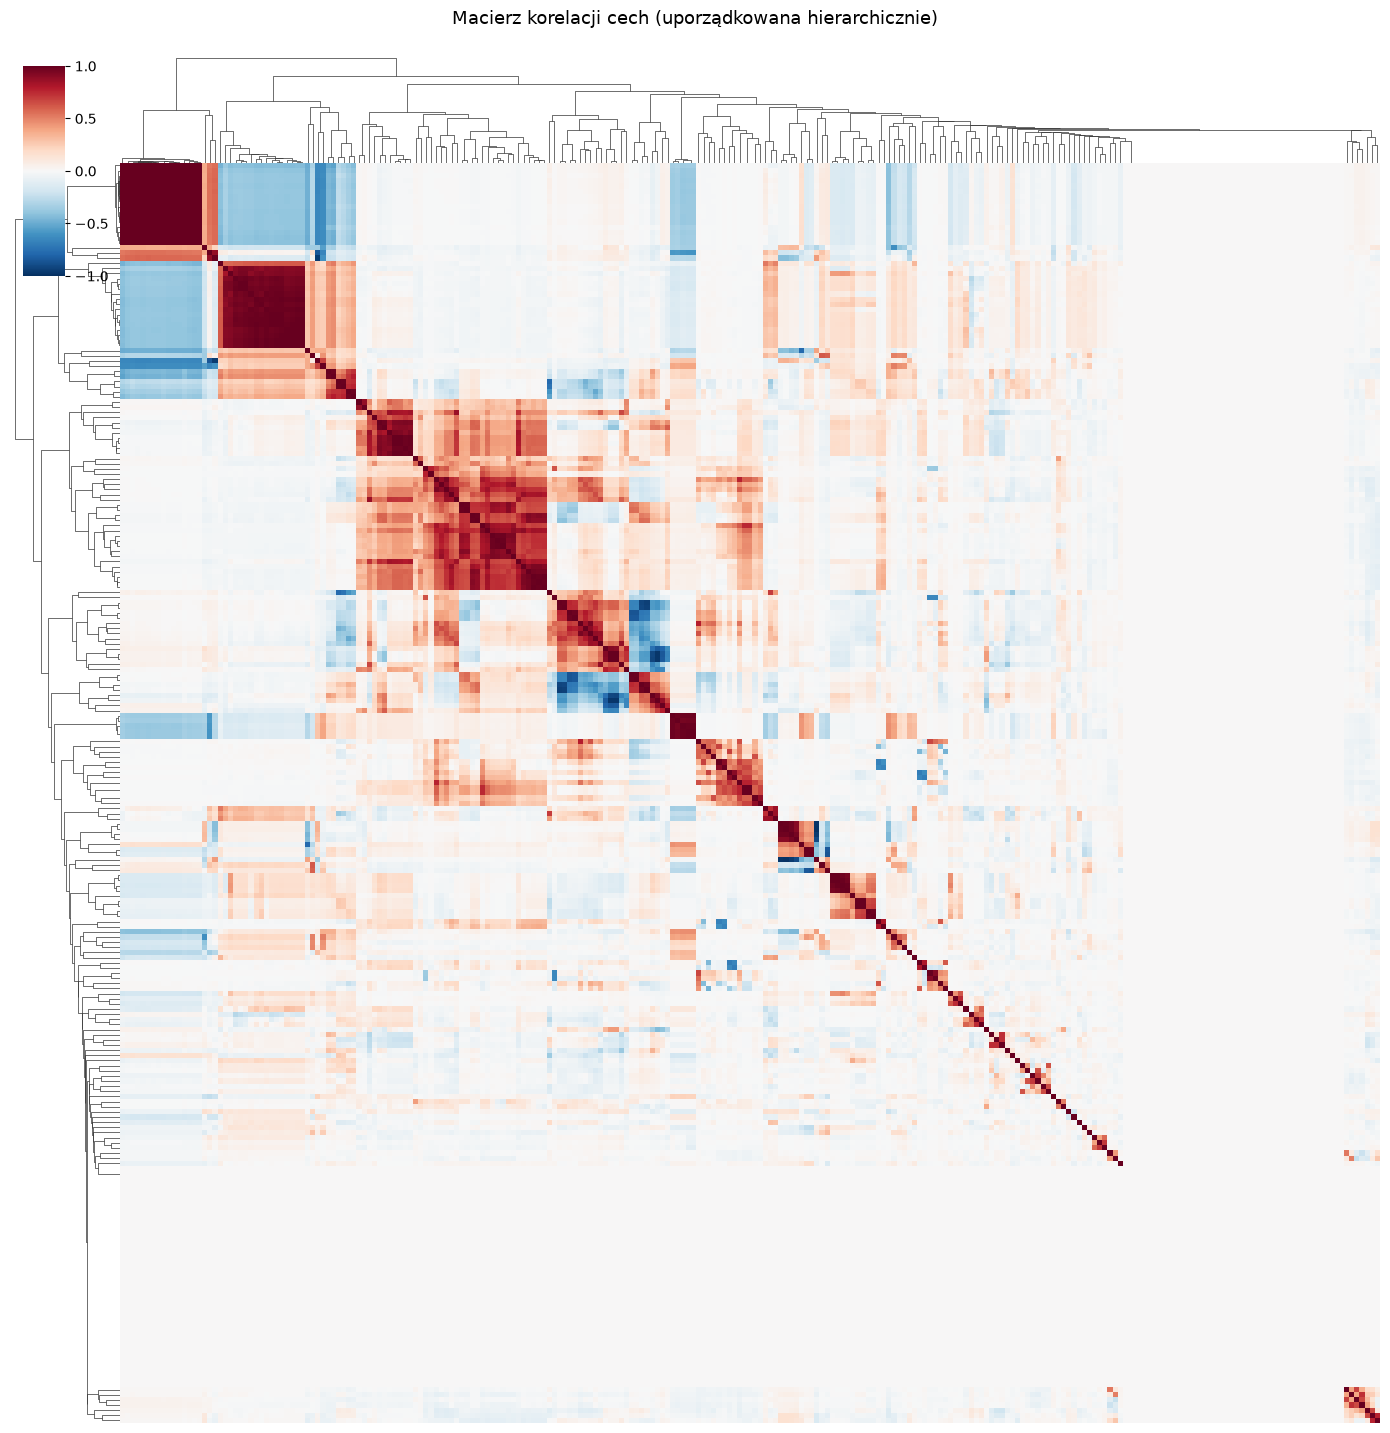

In [55]:
plot_full_clustermap(corr)

Obrazek 1 (pełna macierz, ~200 cech, przed redukcją): widać wyraźnie kilka dużych "czerwonych bloków" — to rodziny cech pochodzące z tej samej kolumny bazowej (różne okna/metody wygładzania). To dokładnie ten sam mechanizm co w moim demo, tylko na prawdziwych danych — dobry dowód, że redukcja redundancji (select_uncorrelated_features) ma sens.

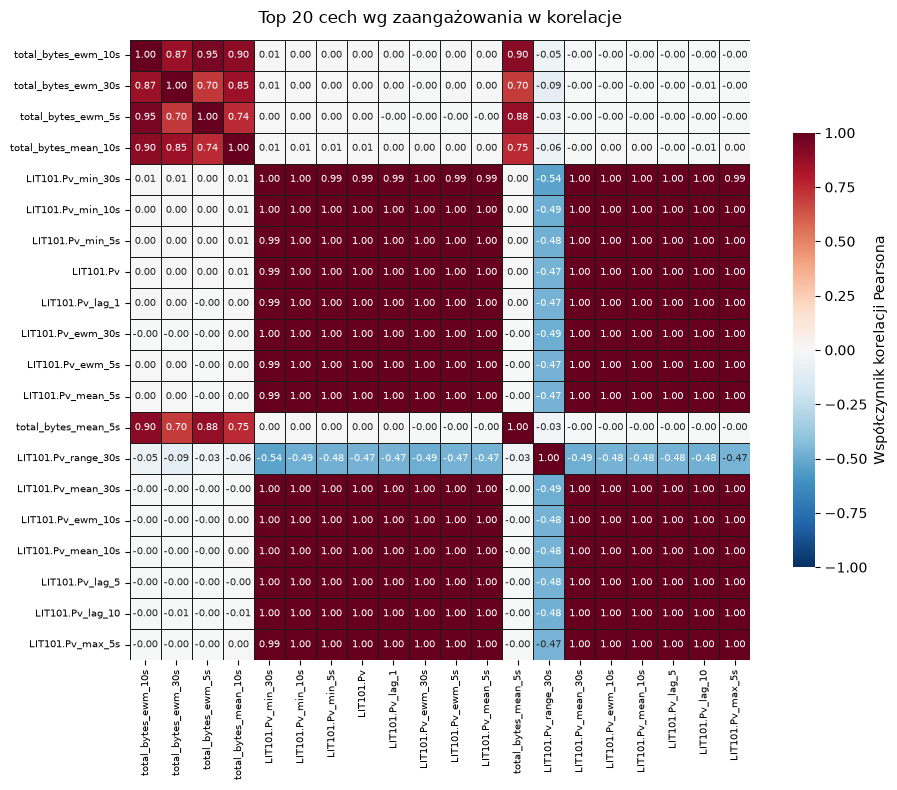

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Top 20 cech wg zaangażowania w korelacje'}>)

In [56]:
plot_top_features_heatmap(corr, top_n=20)

Obrazek 2 (top 20) jest bardzo pouczający:

LIT101.Pv_* (min/max/mean/ewm/lag, wszystkie okna 5s/10s/30s) koreluje ze sobą na poziomie 0.99–1.00 niemal bez wyjątku. To silniejsza redundancja niż u total_bytes_* (0.70–0.95). Sensowne wytłumaczenie: LIT101 (poziom cieczy w zbiorniku) zmienia się wolno — w skali 5-30 sekund praktycznie się nie rusza, więc każde okno "widzi" prawie tę samą wartość. total_bytes (ruch sieciowy) zmienia się znacznie szybciej sekunda-do-sekundy, więc okna różnej długości faktycznie uśredniają różne informacje.
FIT101.Pv_max_10s koreluje ujemnie (~-0.4) z prawie całą rodziną LIT101.Pv, ale dodatnio (0.48) z LIT101.Pv_range_30s — to już relacja międzyzmienna, nie artefakt konstrukcji cech. Fizycznie sensowne: przepływ i poziom w zbiorniku są ze sobą powiązane procesowo.

In [47]:
adf_lit = sa.adf_test(df_out["LIT101.Pv"])
print(adf_lit)

{'adf_statistic': -2.344603704290195, 'p_value': 0.15798549075782903, 'n_lags': 26, 'n_obs': 4334, 'critical_values': {'1%': np.float64(-3.431859731731727), '5%': np.float64(-2.8622071156110476), '10%': np.float64(-2.567125110320964)}, 'is_stationary': False}


"Seeing Birdsong" to projekt art-science, który zamienia nagrania śpiewu ptaków na wielowymiarowe wektory deskryptorów widmowych, osadzone w dynamicznych trójwymiarowych rozmaitościach (manifolds) i wizualizowane jako interaktywne grafy 2D/3D — czyli w praktyce: cechy akustyczne (spektralne) → redukcja wymiarowości → animowana, eksplorowalna geometria w 3D, zamiast statycznego wykresu.

#### t-SNE

In [61]:
from export_data_3d import export_manifold_data_pca, export_manifold_data_tsne

# wersja PCA (szybka, ale pewnie słabo rozdzieli klastry - zgodnie z rozdz. 2.1.4)
export_manifold_data_pca(df_final, output_path="data/manifold_pca.json")

# wersja t-SNE (wolniejsza — dla 4356 punktów potrwa może z minutę,
# ale to ta, która powinna pokazać wyraźnie odseparowany klaster ataku)
export_manifold_data_tsne(df_final, output_path="data/manifold_tsne.json")

Wyjaśniona wariancja (PC1, PC2, PC3): [0.1064, 0.0725, 0.0513] (suma: 0.230)
[pca] zapisano 4000 punktów do data/manifold_pca.json
t-SNE: perplexity=30, punktów=3000, cech wejściowych=123
[tsne] zapisano 3000 punktów do data/manifold_tsne.json


{'method': 'tsne',
 'n_points': 3000,
 'n_features_input': 123,
 'points': [{'t': 0,
   'pc1': -0.18225,
   'pc2': -0.08521,
   'pc3': -0.87683,
   'y': 0},
  {'t': 1, 'pc1': -0.18242, 'pc2': -0.08514, 'pc3': -0.8769, 'y': 0},
  {'t': 2, 'pc1': -0.18245, 'pc2': -0.08514, 'pc3': -0.87692, 'y': 0},
  {'t': 3, 'pc1': -0.20953, 'pc2': -0.12859, 'pc3': -0.94137, 'y': 0},
  {'t': 4, 'pc1': -0.18223, 'pc2': -0.16017, 'pc3': -1.0, 'y': 0},
  {'t': 5, 'pc1': -0.1796, 'pc2': -0.16548, 'pc3': -0.98889, 'y': 0},
  {'t': 6, 'pc1': -0.18162, 'pc2': -0.17059, 'pc3': -0.97499, 'y': 0},
  {'t': 7, 'pc1': -0.1847, 'pc2': -0.18191, 'pc3': -0.95694, 'y': 0},
  {'t': 8, 'pc1': -0.174, 'pc2': -0.17733, 'pc3': -0.95444, 'y': 0},
  {'t': 9, 'pc1': -0.09869, 'pc2': -0.1707, 'pc3': -0.92314, 'y': 0},
  {'t': 10, 'pc1': -0.09812, 'pc2': -0.17097, 'pc3': -0.91845, 'y': 0},
  {'t': 11, 'pc1': -0.10187, 'pc2': -0.16796, 'pc3': -0.97128, 'y': 0},
  {'t': 12, 'pc1': -0.14617, 'pc2': -0.18852, 'pc3': -0.9369, 'y': 0},

Mam hipotezę, dlaczego może wyjść gorzej niż u koleżanki w rozdziale 2: Twój zbiór cech ma bardzo silną autokorelację czasową — sama to znalazłaś wcześniej (setki par cech na poziomie 0.99+ dla _mean_5s/_ewm_5s/_lag_1 tej samej kolumny). t-SNE grupuje punkty na podstawie podobieństwa w przestrzeni cech, a skoro sąsiednie momenty czasowe mają niemal identyczne wartości tych rolling-cech (bo się nakładają oknami), to t-SNE może grupować głównie wg czasu/ciągłości trajektorii, a nie wg y. Kolejka atak-normalny może więc "przeciekać" płynnie, zamiast tworzyć osobną wyspę — dokładnie to widzę we fragmentach danych, które wkleiłaś (t≈2131-2255, y=1 ma bardzo podobne współrzędne do sąsiednich y=0).